In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("../Data/car.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [4]:
df.shape

(4340, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [6]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [7]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

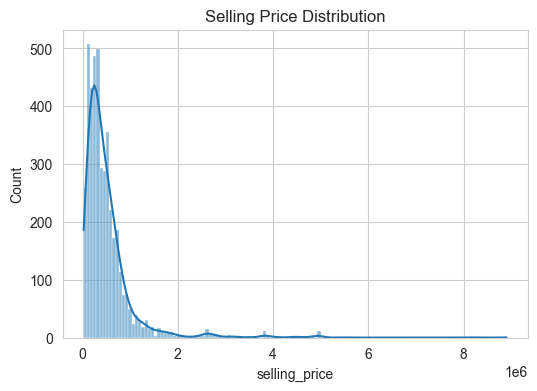

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df['selling_price'], kde=True)
plt.title("Selling Price Distribution")
plt.show()

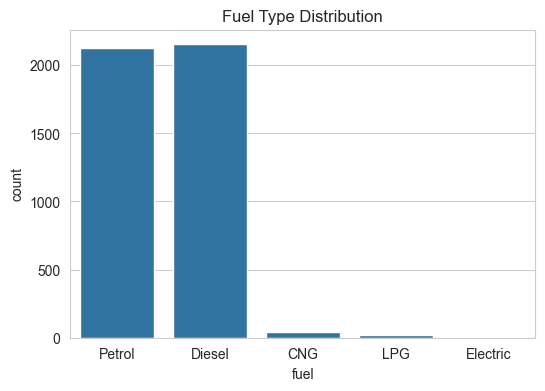

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='fuel', data=df)
plt.title("Fuel Type Distribution")
plt.show()

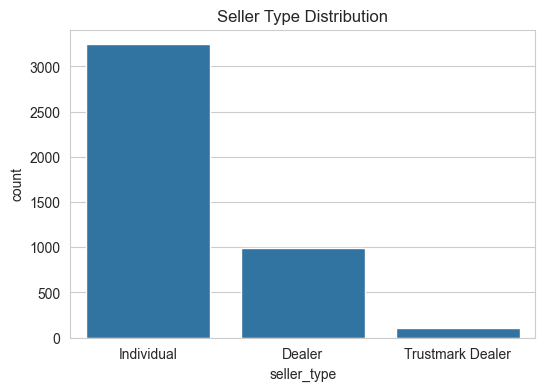

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='seller_type', data=df)
plt.title("Seller Type Distribution")
plt.show()

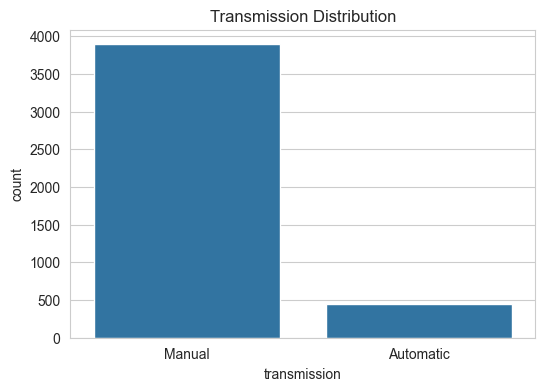

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='transmission', data=df)
plt.title("Transmission Distribution")
plt.show()

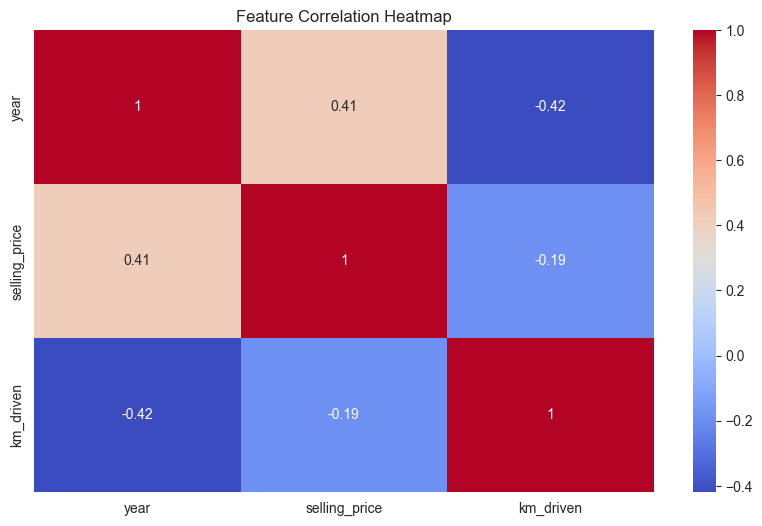

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [13]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,year,selling_price,km_driven,name_Ambassador Classic 2000 Dsz,name_Ambassador Grand 1800 ISZ MPFI PW CL,name_Audi A4 1.8 TFSI,name_Audi A4 2.0 TDI,name_Audi A4 2.0 TDI 177 Bhp Premium Plus,name_Audi A4 3.0 TDI Quattro,name_Audi A4 30 TFSI Technology,...,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2007,60000,70000,False,False,False,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False
1,2007,135000,50000,False,False,False,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False
2,2012,600000,100000,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
3,2017,250000,46000,False,False,False,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False
4,2014,450000,141000,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,True,False,False


In [14]:
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [18]:
print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("Linear Regression MAE:", mean_absolute_error(y_test, lr_pred))

Linear Regression R2: 0.5749091498668156
Linear Regression MAE: 121650.22263042434


In [19]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [20]:
print("Random Forest R2:", r2_score(y_test, rf_pred))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))

Random Forest R2: 0.5746311417691606
Random Forest MAE: 118771.85072822032


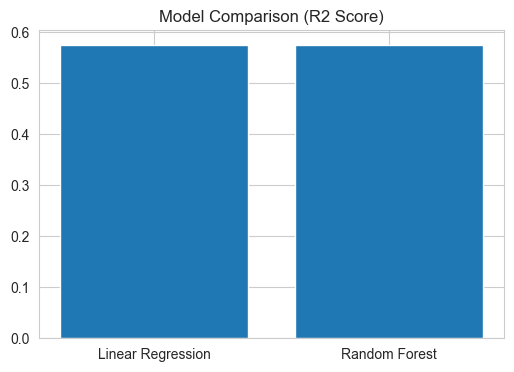

In [21]:
models = ["Linear Regression", "Random Forest"]
scores = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, rf_pred)
]

plt.figure(figsize=(6,4))
plt.bar(models, scores)
plt.title("Model Comparison (R2 Score)")
plt.show()